# New World Development Financial Breakdown

In [11]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

### Data

In [12]:
df = pd.read_excel("../data/NWD Financial Positions.xlsx", header=0, na_values="N.A.")
df = df.rename(columns={'NWD Financial Statement Breakdown': 'Segment'})
df

,Segment,2025,2024,2023,2022,2021,2020,2019,2018,2017,2016,2015,2014,2013
0,Revenue,27680.500,35782.200,95213.800,68212.700,68233.200,59007.800,76763.600,60688.700,56628.800,59570.000,55245.000,56501.100,46779.900
1,Gross profit,11625.800,12849.200,21449.500,18245.700,19151.200,19931.200,25021.500,20563.400,18215.600,18522.400,19306.000,21553.500,18425.300
2,Operating Profit,-8283.400,488.600,11111.200,8133.000,8528.900,12035.400,25202.100,30975.300,11751.300,16583.300,27970.900,16823.100,19286.700
3,Profit before taxation,-13835.400,-4748.400,10096.300,9214.500,10365.500,10794.400,29128.900,33353.600,15230.300,18707.100,31136.500,19076.000,23311.200
4,Profit from continuing operations,-16356.600,-9810.800,4080.900,1882.000,4703.900,3266.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Profit for the year,-16356.600,-17125.900,4080.900,4301.800,4703.900,3266.400,21639.100,27081.200,10474.700,12283.400,26872.100,13337.800,18516.400
6,Total non-current assets,313688.800,327142.800,444085.300,442716.100,419012.700,417924.000,353120.200,309399.700,258075.300,233170.900,236183.000,214036.300,206050.100
7,Total current assets,105021.300,116254.000,172397.900,193147.700,208064.700,182271.900,150164.700,172055.100,178981.000,158937.700,161747.700,154668.100,124594.600
8,Total Assets,420265.000,445157.600,616483.200,635883.900,627077.400,600195.900,503284.900,481454.800,437056.300,392108.600,397930.700,369227.400,332189.100
9,Total equity,206736.900,224888.800,268491.400,288098.800,304192.400,279745.100,275364.500,255181.900,220944.500,200895.300,222358.000,200276.500,177745.000


### Plot 1:  Net Debt vs Cash

In [13]:
columns = ['Net Debt', 'Cash and cash equivalents at end of the year']
p1 = df[df['Segment'].isin(columns)].copy()
p1 = p1.melt(id_vars='Segment', var_name="Year", value_name="Amount")
p1['Amount'] = p1['Amount']/1000

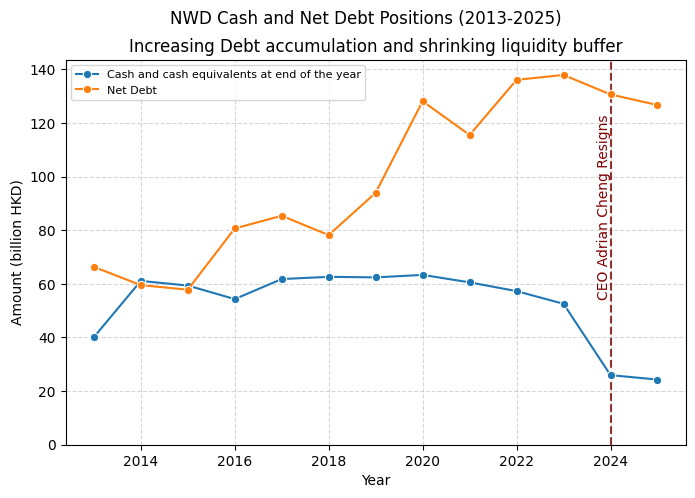

In [14]:
fig, ax = plt.subplots(figsize = (8,5))

sns.lineplot(data=p1, x = "Year", y= "Amount",
             hue= "Segment", legend= True, 
             marker = "o", ax = ax, zorder = 3)
ax.set(ylabel= "Amount (billion HKD)", title= 'Increasing Debt accumulation and shrinking liquidity buffer')
ax.legend(loc = "upper left", fontsize = 8)
ax.grid(True, alpha = 0.5, linestyle = "--", zorder = 0)
ax.set_ylim(bottom=0)
ax.axvline(x = 2024, linestyle = "--", alpha = 0.8, zorder = 2, color = "maroon")
ax.annotate("CEO Adrian Cheng Resigns", xy=(2024, 85), rotation = 90, ha = "right", xytext=(2024,55), color = "maroon")
fig.suptitle("NWD Cash and Net Debt Positions (2013-2025)")
plt.show()

### Plot 2: Operating Profits

In [15]:
p2 = df[df['Segment'] == 'Operating Profit'].copy()
p2 = p2.melt(id_vars="Segment", value_name= "Amount", var_name="Year")
p2['Amount'] = p2['Amount']/1000

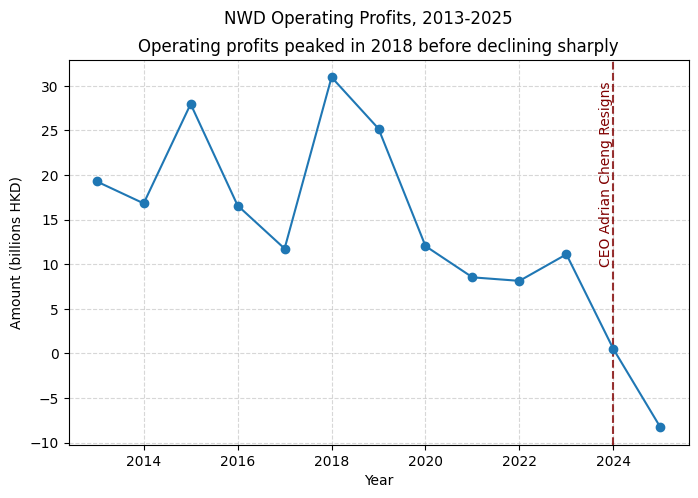

In [16]:
fig, ax = plt.subplots(figsize = (8,5))
ax.plot(p2['Year'], p2['Amount'], marker ="o", zorder = 3)
ax.grid(True, linestyle = "--", alpha = 0.5, zorder = 0)
ax.set(xlabel="Year", ylabel="Amount (billions HKD)", title = "Operating profits peaked in 2018 before declining sharply")
ax.axvline(x = 2024, linestyle = "--", alpha = 0.8, zorder = 2, color = "maroon")
ax.annotate("CEO Adrian Cheng Resigns", xy=(2024, 25), rotation = 90, ha = "right", xytext=(2024,10), color = "maroon")
fig.suptitle("NWD Operating Profits, 2013-2025")
plt.show()

### Plot 3: Gearing Ratio - Net Debt/ Total Equity

In [17]:
p3 = df[df['Segment'] == "Gearing Ratio"].copy()
p3 = p3.melt(id_vars= "Segment", var_name="Year", value_name="Amount")
p3['Amount'] = p3['Amount'] * 100

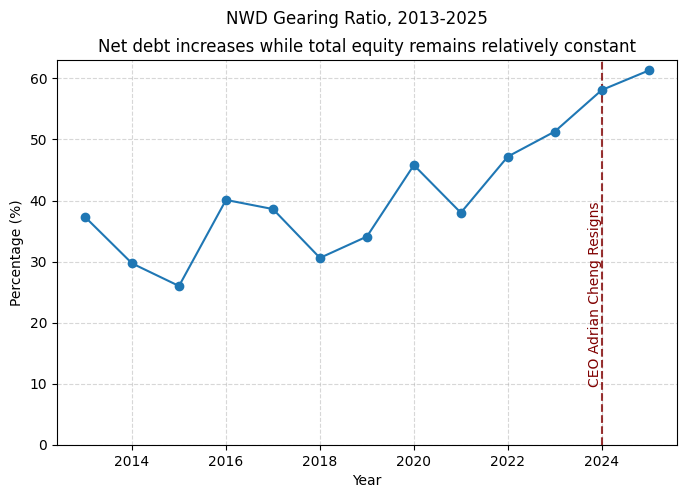

In [18]:
fig, ax = plt.subplots(figsize =(8,5))

ax.plot(p3['Year'], p3['Amount'], marker = "o", zorder = 3)
ax.grid(True, alpha = 0.5, linestyle = "--", zorder = 0)
ax.set(xlabel="Year", ylabel="Percentage (%)", title= "Net debt increases while total equity remains relatively constant")
ax.axvline(x = 2024, linestyle = "--", alpha = 0.8, zorder = 2, color = "maroon")
ax.set_ylim(bottom=0)
ax.annotate("CEO Adrian Cheng Resigns", xy=(2024, 25), rotation = 90, ha = "right", xytext=(2024,10), color = "maroon")

fig.suptitle("NWD Gearing Ratio, 2013-2025")

plt.show()

### Plot 4: Cash Flow Composition

In [19]:
columns = ['Net cash from operating activities', 'Net cash from investing activities', 'Net cash from financing activities']
p4 = df[df['Segment'].isin(columns)].copy()
p4 = p4.melt(id_vars="Segment", var_name= "Year", value_name="Amount")
p4['Amount'] = p4['Amount']/1000

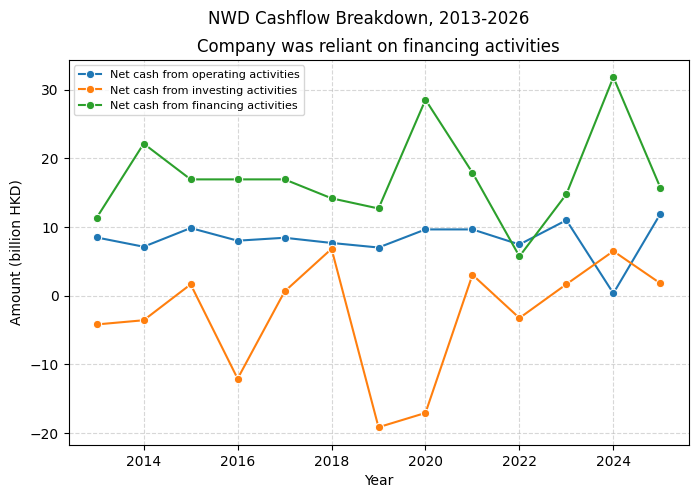

In [20]:
fig, ax = plt.subplots(figsize = (8,5))

sns.lineplot(data=p4, x = "Year", y = "Amount",
             hue = "Segment", legend=True,
             zorder = 3, ax=ax, marker = "o")

ax.legend(fontsize = 8)
ax.set(ylabel="Amount (billion HKD)", title = "Company was reliant on financing activities")
ax.grid(True, linestyle = "--", alpha = 0.5, zorder =0)

fig.suptitle("NWD Cashflow Breakdown, 2013-2026")

plt.show()

### Next Steps:
* Find out exactly when New World Development became visibly weak
* How Competitors reacted to this competition shock event 
* What kind of reaction can be studied

In [21]:
import yfinance as yf

data = yf.download("^hsnp", start="2013-01-01", end="2026-05-17", progress= False)
hsnp = data['Close']
hsnp = hsnp.reset_index()
hsnp.columns.name = None

data = yf.download("0017.HK", start="2013-01-01", end="2026-05-17", progress= False)
nwd = data['Close']
nwd = nwd.reset_index()
nwd.columns.name = None

In [24]:
hsnp

,Date,^HSNP
0,2013-01-02,32205.619141
1,2013-01-03,32083.220703
2,2013-01-04,32340.259766
3,2013-01-07,32874.031250
4,2013-01-08,32615.160156
...,...,...
3281,2026-05-11,23015.730469
3282,2026-05-12,22770.210938
3283,2026-05-13,22766.289062
3284,2026-05-14,22987.599609


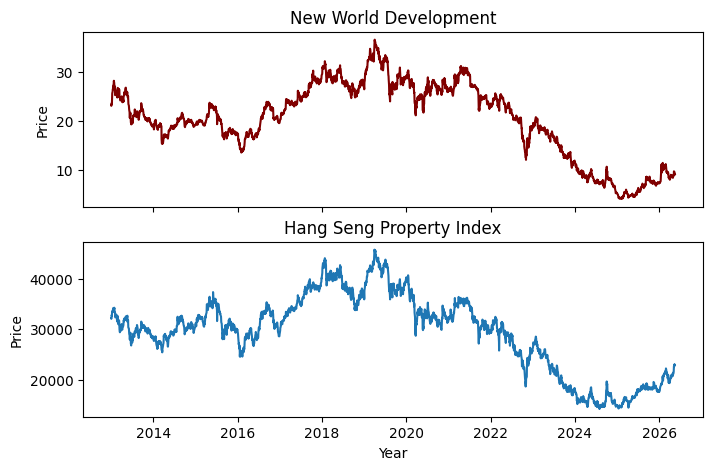

In [32]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex= True, figsize = (8,5))

ax1.plot(nwd['Date'], nwd['0017.HK'], label = "New World Development", color = "maroon")
ax1.set(xlabel="", ylabel="Price", title="New World Development")
ax2.plot(hsnp['Date'], hsnp['^HSNP'], label = "Hang Seng Property Index")
ax2.set(xlabel="Year", ylabel="Price", title = "Hang Seng Property Index")

plt.show()